# 1) Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# 2) Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\deore\FullStack Data Science course\Machine Learning Tasks\Cancer_Mortality_Regression\cancer_reg.csv",encoding="latin1")

In [4]:
df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


# 3) Check Dataset Size

In [5]:
print("Number of rows:", df.shape[0])
print("Numbe of columns:",df.shape[1])

Number of rows: 3047
Numbe of columns: 34


# 4) Check Column Names

In [6]:
df.columns.tolist()

['avgAnnCount',
 'avgDeathsPerYear',
 'TARGET_deathRate',
 'incidenceRate',
 'medIncome',
 'popEst2015',
 'povertyPercent',
 'studyPerCap',
 'binnedInc',
 'MedianAge',
 'MedianAgeMale',
 'MedianAgeFemale',
 'Geography',
 'AvgHouseholdSize',
 'PercentMarried',
 'PctNoHS18_24',
 'PctHS18_24',
 'PctSomeCol18_24',
 'PctBachDeg18_24',
 'PctHS25_Over',
 'PctBachDeg25_Over',
 'PctEmployed16_Over',
 'PctUnemployed16_Over',
 'PctPrivateCoverage',
 'PctPrivateCoverageAlone',
 'PctEmpPrivCoverage',
 'PctPublicCoverage',
 'PctPublicCoverageAlone',
 'PctWhite',
 'PctBlack',
 'PctAsian',
 'PctOtherRace',
 'PctMarriedHouseholds',
 'BirthRate']

# 5) Basic information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

# 4) Check missing values

In [8]:
# Check missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

PctSomeCol18_24            2285
PctPrivateCoverageAlone     609
PctEmployed16_Over          152
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

PctSomeCol18_24            74.991795
PctPrivateCoverageAlone    19.986872
PctEmployed16_Over          4.988513
dtype: float64

# Check duplicate rows

In [10]:
# Number of duplicate rows

df.duplicated().sum()

np.int64(0)

In [11]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
avgAnnCount,3047.0,606.338544,1416.356223,6.000000,76.000000,171.000000,518.000000,3.815000e+04
avgDeathsPerYear,3047.0,185.965868,504.134286,3.000000,28.000000,61.000000,149.000000,1.401000e+04
TARGET_deathRate,3047.0,178.664063,27.751511,59.700000,161.200000,178.100000,195.200000,3.628000e+02
incidenceRate,3047.0,448.268586,54.560733,201.300000,420.300000,453.549422,480.850000,1.206900e+03
medIncome,3047.0,47063.281917,12040.090836,22640.000000,38882.500000,45207.000000,52492.000000,1.256350e+05
popEst2015,3047.0,102637.370528,329059.220504,827.000000,11684.000000,26643.000000,68671.000000,1.017029e+07
povertyPercent,3047.0,16.878175,6.409087,3.200000,12.150000,15.900000,20.400000,4.740000e+01
studyPerCap,3047.0,155.399415,529.628366,0.000000,0.000000,0.000000,83.650776,9.762309e+03
MedianAge,3047.0,45.272333,45.304480,22.300000,37.700000,41.000000,44.000000,6.240000e+02
MedianAgeMale,3047.0,39.570725,5.226017,22.400000,36.350000,39.600000,42.500000,6.470000e+01


In [12]:
# Check categorical columns

df.select_dtypes(include="object").columns.tolist()

['binnedInc', 'Geography']

In [13]:
# Check unique values in categorical columns

for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print("Unique values:", df[col].nunique())
    print(df[col].head())


 binnedInc
Unique values: 10
0     (61494.5, 125635]
1    (48021.6, 51046.4]
2    (48021.6, 51046.4]
3      (42724.4, 45201]
4    (48021.6, 51046.4]
Name: binnedInc, dtype: object

 Geography
Unique values: 3047
0       Kitsap County, Washington
1     Kittitas County, Washington
2    Klickitat County, Washington
3        Lewis County, Washington
4      Lincoln County, Washington
Name: Geography, dtype: object


In [14]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['binnedInc', 'Geography']


In [15]:
# Unique values
for col in categorical_columns:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


binnedInc
Number of unique values: 10
binnedInc
(54545.6, 61494.5]    306
[22640, 34218.1]      306
(45201, 48021.6]      306
(48021.6, 51046.4]    305
(42724.4, 45201]      305
(51046.4, 54545.6]    305
(37413.8, 40362.7]    304
(40362.7, 42724.4]    304
(34218.1, 37413.8]    304
(61494.5, 125635]     302
Name: count, dtype: int64

Geography
Number of unique values: 3047
Geography
Kitsap County, Washington    1
Ralls County, Missouri       1
Pemiscot County, Missouri    1
Perry County, Missouri       1
Pettis County, Missouri      1
Phelps County, Missouri      1
Pike County, Missouri        1
Platte County, Missouri      1
Polk County, Missouri        1
Pulaski County, Missouri     1
Name: count, dtype: int64


# 5) Handle missing values

In [16]:

df["PctSomeCol18_24"].isna().sum()

np.int64(2285)

In [17]:
df = df.drop("PctSomeCol18_24", axis =1)

In [18]:
# check the number of columns
print("Number of columns:",df.shape[1])

Number of columns: 33


In [19]:
df["PctEmployed16_Over"] = df["PctEmployed16_Over"].fillna(
    df["PctEmployed16_Over"].median()
)

In [20]:
df["PctPrivateCoverageAlone"] = df["PctPrivateCoverageAlone"].fillna(
    df["PctPrivateCoverageAlone"].median()
)

In [21]:
# check missing values
df.isna().sum()

avgAnnCount                0
avgDeathsPerYear           0
TARGET_deathRate           0
incidenceRate              0
medIncome                  0
popEst2015                 0
povertyPercent             0
studyPerCap                0
binnedInc                  0
MedianAge                  0
MedianAgeMale              0
MedianAgeFemale            0
Geography                  0
AvgHouseholdSize           0
PercentMarried             0
PctNoHS18_24               0
PctHS18_24                 0
PctBachDeg18_24            0
PctHS25_Over               0
PctBachDeg25_Over          0
PctEmployed16_Over         0
PctUnemployed16_Over       0
PctPrivateCoverage         0
PctPrivateCoverageAlone    0
PctEmpPrivCoverage         0
PctPublicCoverage          0
PctPublicCoverageAlone     0
PctWhite                   0
PctBlack                   0
PctAsian                   0
PctOtherRace               0
PctMarriedHouseholds       0
BirthRate                  0
dtype: int64

In [22]:
df.describe()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,...,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,...,48.502987,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,...,9.019423,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,...,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,...,43.100000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,...,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,...,53.800000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,...,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


# 6) Handle the outlier


In [23]:
# create a variable contianing numerical columns
numeric_columns = df.select_dtypes(include="number").columns

print(numeric_columns)

Index(['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate',
       'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'MedianAge',
       'MedianAgeMale', 'MedianAgeFemale', 'AvgHouseholdSize',
       'PercentMarried', 'PctNoHS18_24', 'PctHS18_24', 'PctBachDeg18_24',
       'PctHS25_Over', 'PctBachDeg25_Over', 'PctEmployed16_Over',
       'PctUnemployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone',
       'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone',
       'PctWhite', 'PctBlack', 'PctAsian', 'PctOtherRace',
       'PctMarriedHouseholds', 'BirthRate'],
      dtype='object')


In [24]:
# Find all columns containing outliers using IQR
outlier_columns = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    if len(outliers) > 0:
        outlier_columns.append(col)

print("Columns containing outliers:")
print(outlier_columns)

Columns containing outliers:
['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate', 'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24', 'PctBachDeg18_24', 'PctHS25_Over', 'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack', 'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate']


In [25]:
# clip the outliers using IQR

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

In [26]:
# verify that the outliers were clipped
remaining_outliers = {}

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    if count > 0:
        remaining_outliers[col] = count

print(remaining_outliers)

{}


# 7) Box for numberical columns 

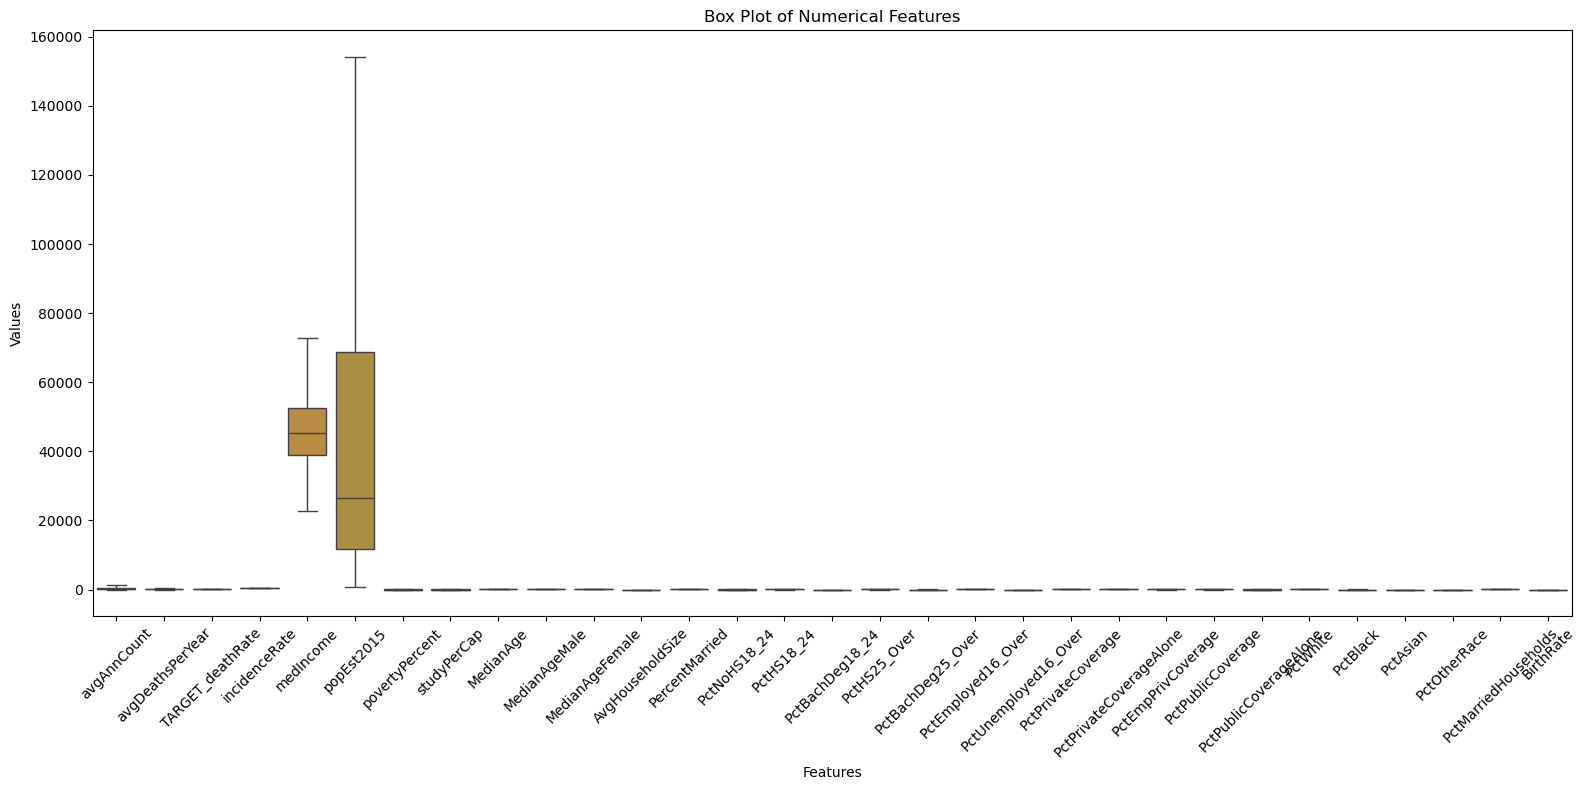

In [27]:
# Select numerical columns
numeric_columns = df.select_dtypes(include="number").columns

# Create box plot
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[numeric_columns])

plt.title("Box Plot of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8) Check the outliers using seaparte box plot for each column

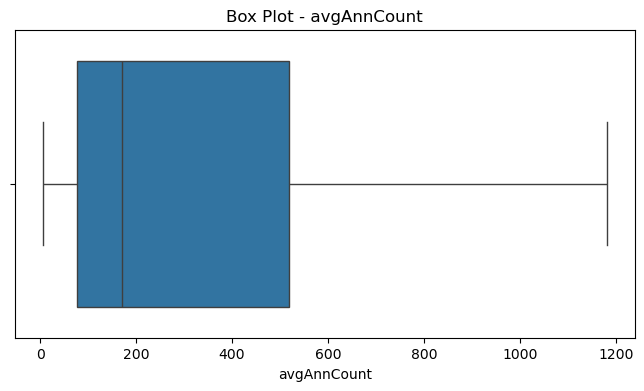

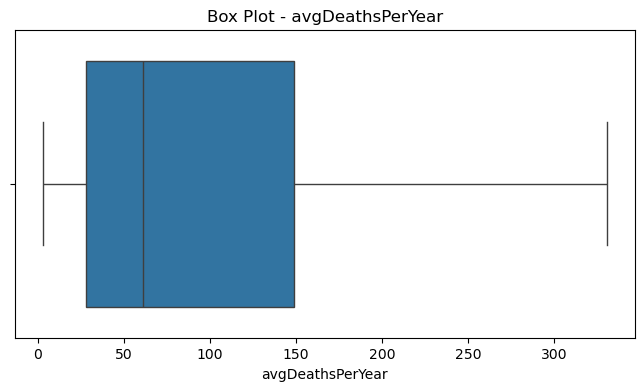

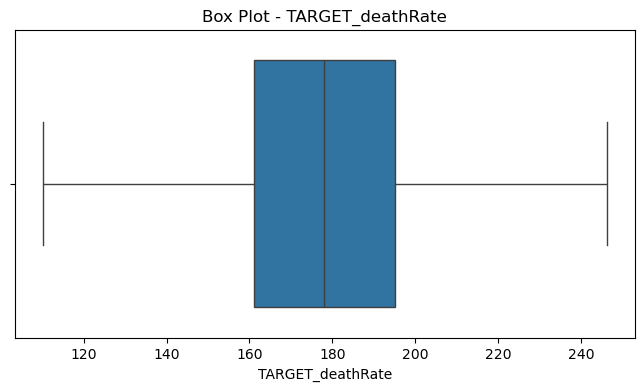

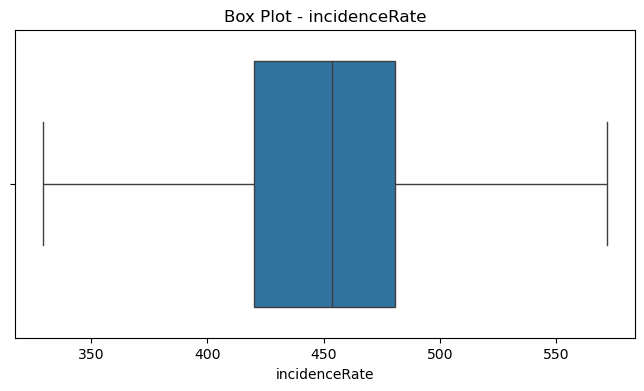

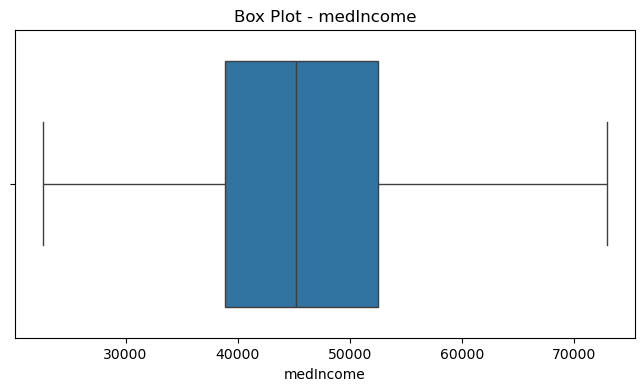

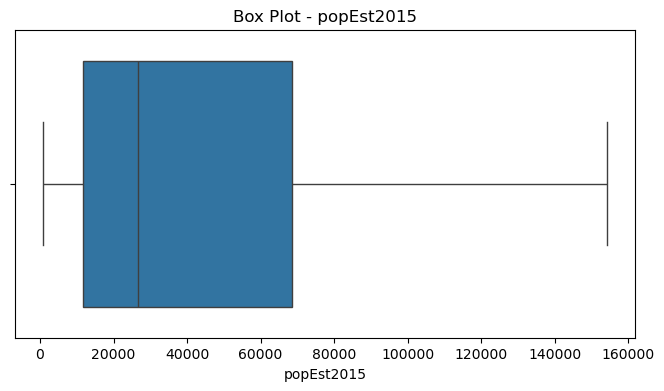

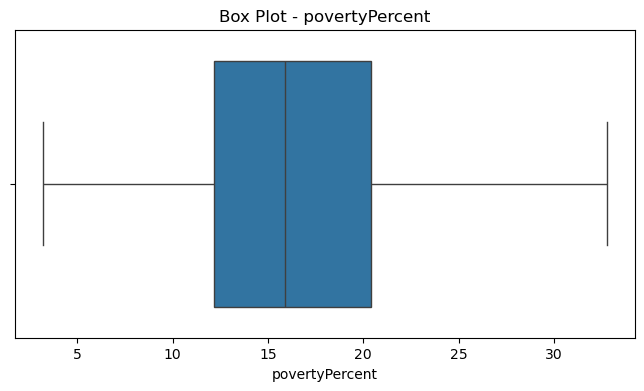

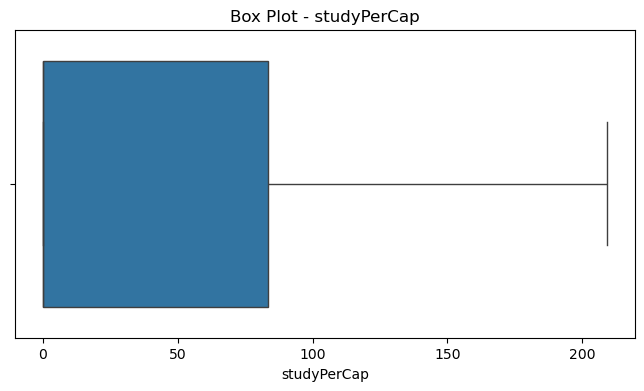

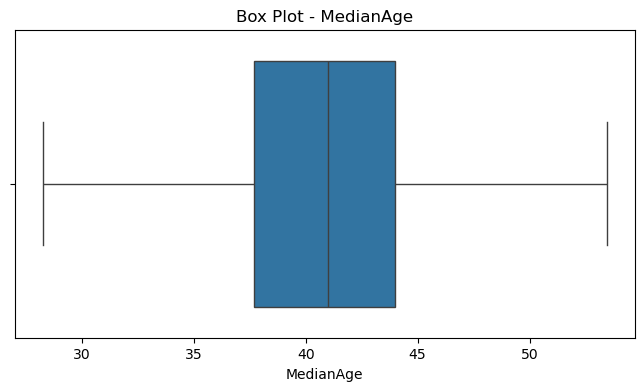

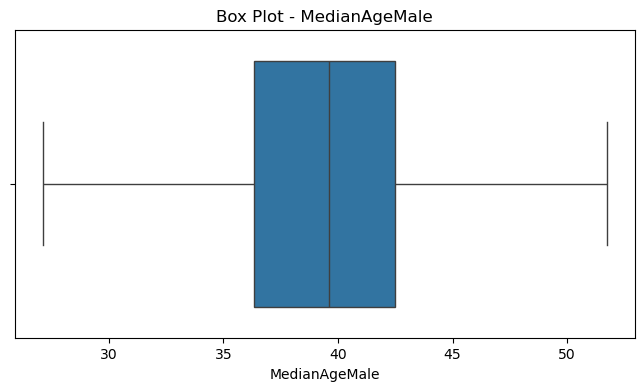

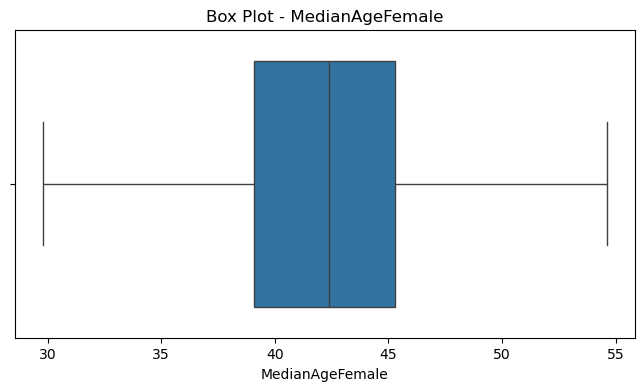

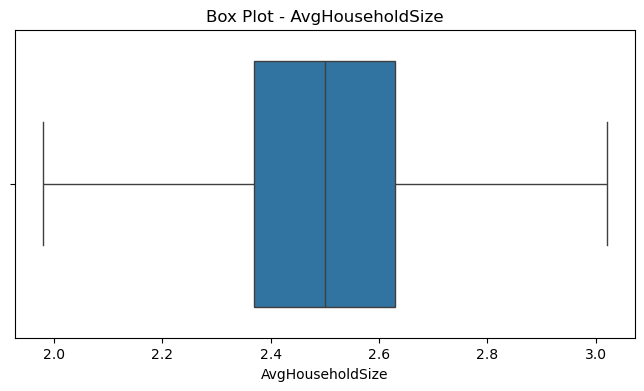

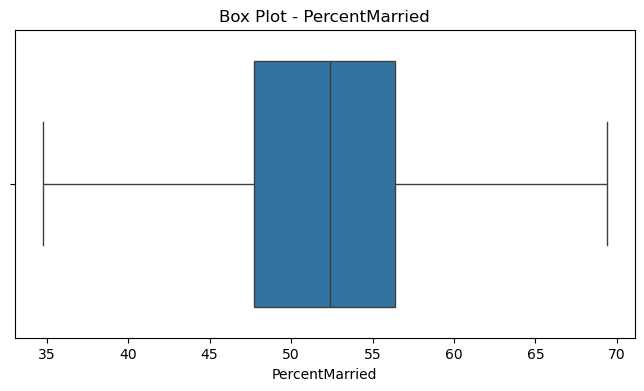

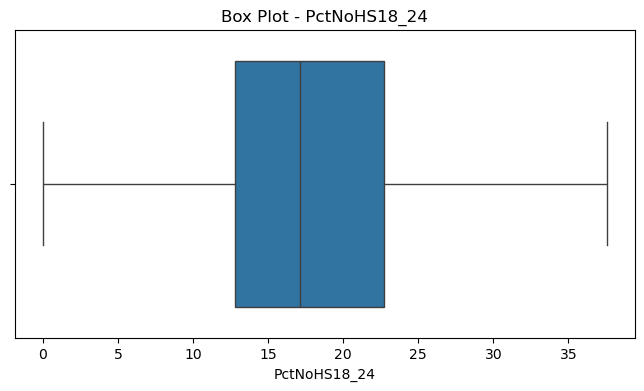

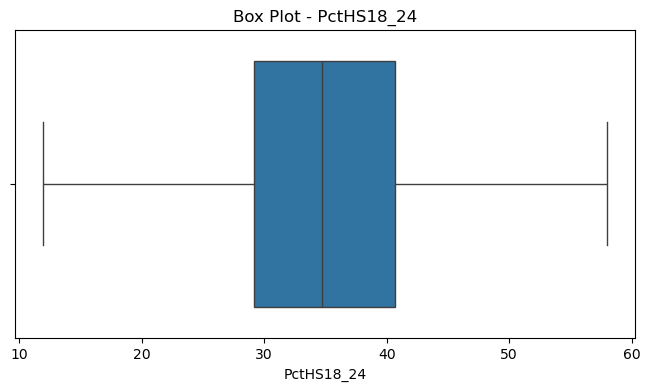

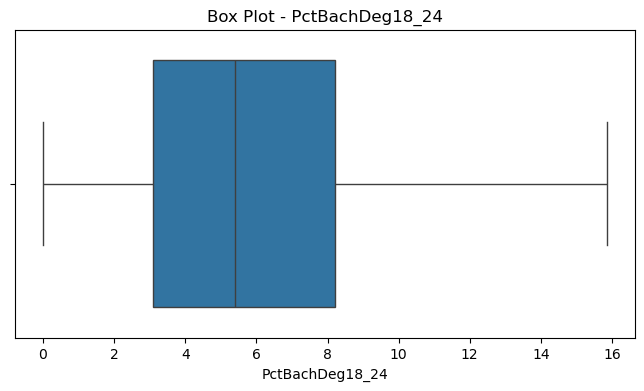

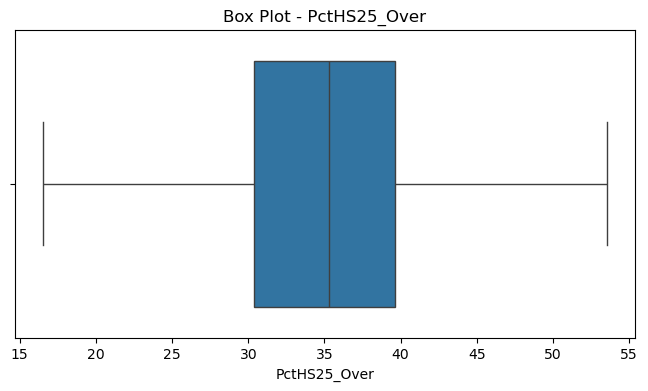

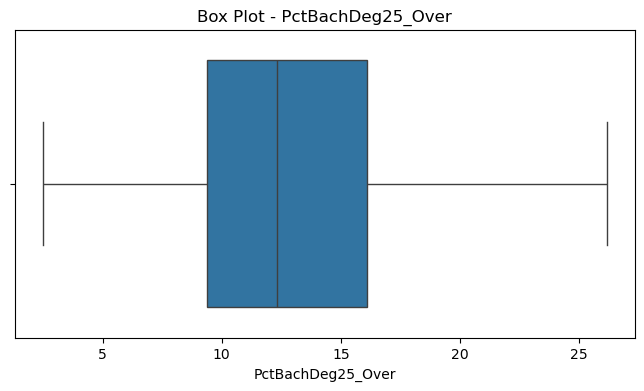

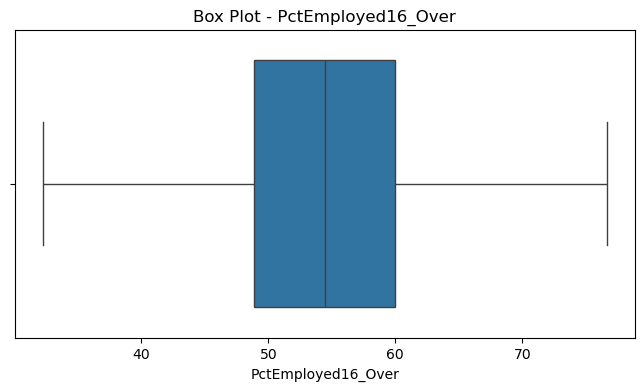

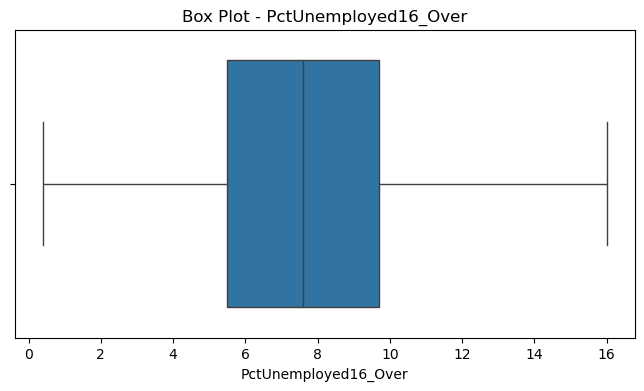

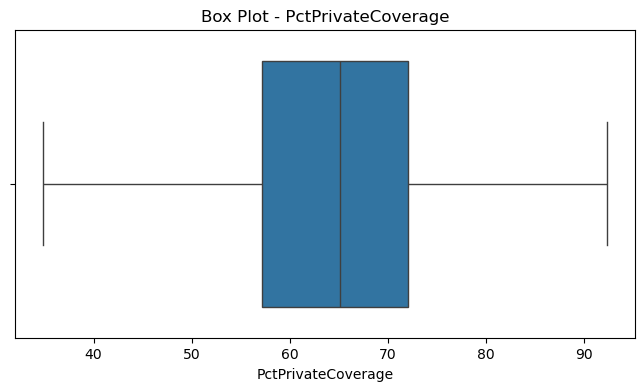

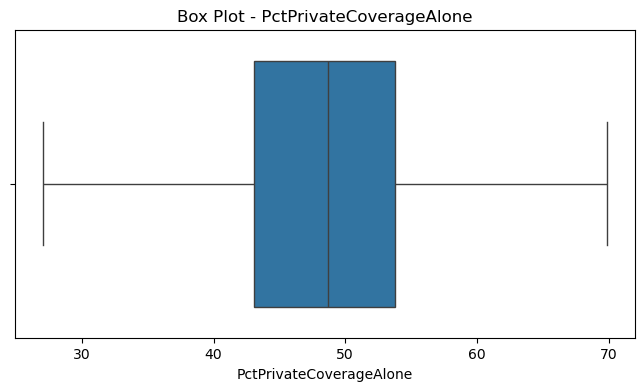

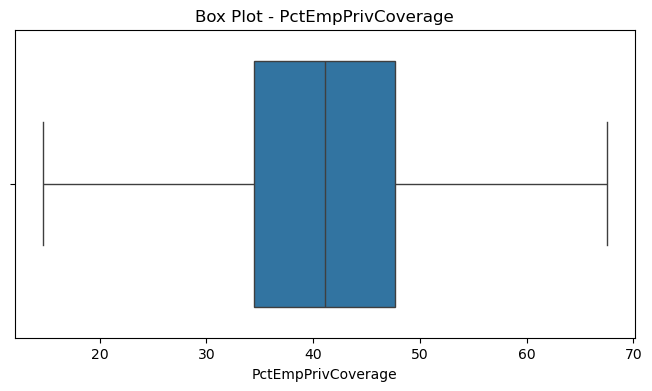

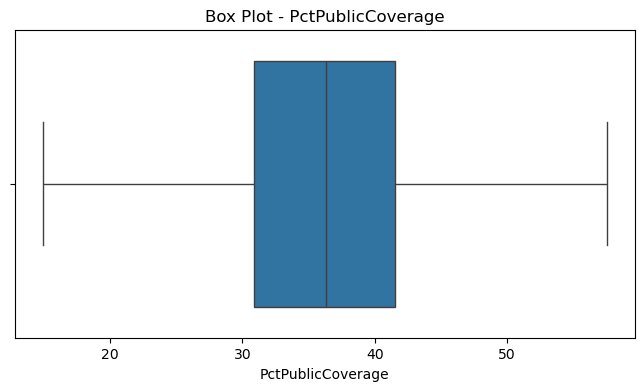

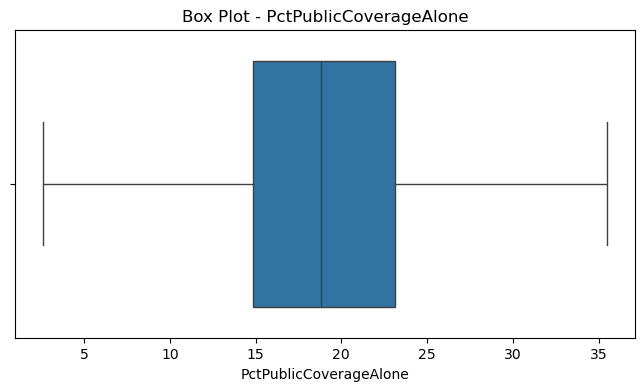

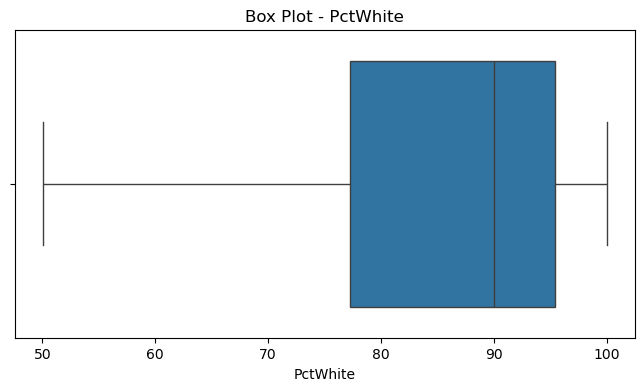

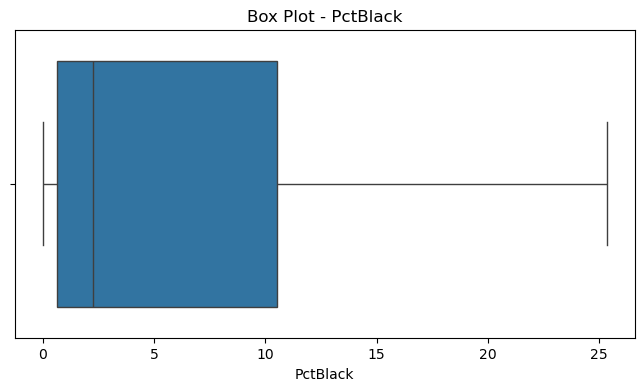

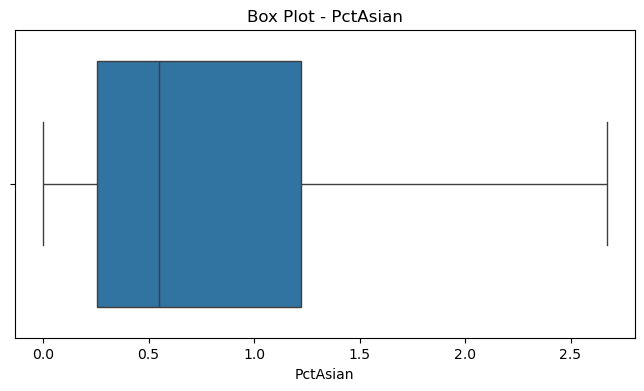

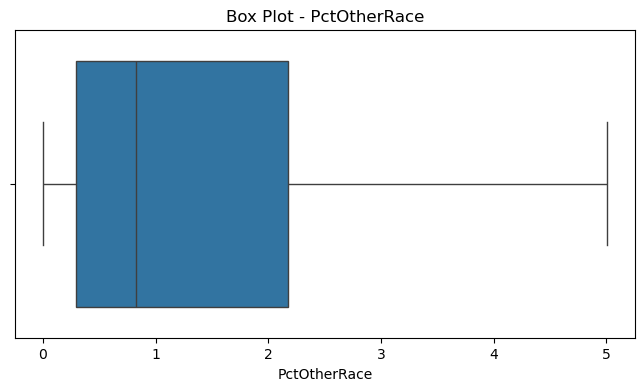

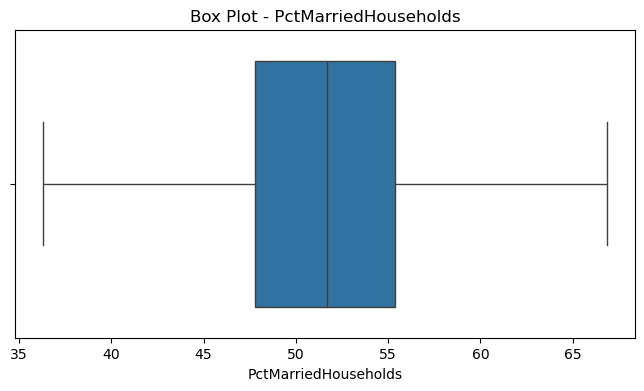

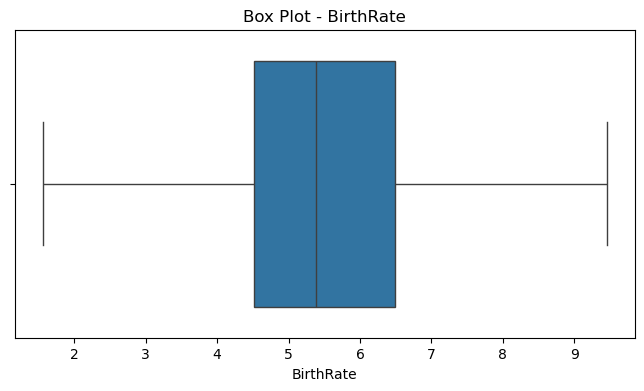

In [29]:




for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Box Plot - {column}")
    plt.xlabel(column)
    
    plt.show()

In [30]:
# check the rows of the dataset
print("Rows of the dataset:",df.shape[0])

Rows of the dataset: 3047


# Model buildin

## 1) Select X and y

In [62]:
X = df[["PctPublicCoverageAlone"]]
y = df["TARGET_deathRate"]

## 2) Train - Test Split

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2437, 1)
X_test : (610, 1)
y_train: (2437,)
y_test : (610,)


## 3) Feature Scaling

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4) Build Linear regression model

In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


## 5) Make Predictions

In [66]:
y_pred = model.predict(X_test_scaled)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[185.50390665 167.21328014 162.64062352 182.12411697 176.75621571
 157.86915573 169.99663635 175.76215993 161.44775657 172.97880372]


## 6) Evaluate the Model

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Simple Linear Regression")
print("-----------------------")
print("Feature: PctPublicCoverageAlone")
print("Target : TARGET_deathRate")
print()
print("MAE  :", MAE)
print("MSE  :", MSE)
print("RMSE :", RMSE)
print("R²   :", R2)

Simple Linear Regression
-----------------------
Feature: PctPublicCoverageAlone
Target : TARGET_deathRate

MAE  : 18.709654452181944
MSE  : 586.1174497424146
RMSE : 24.209862654348424
R²   : 0.2299829766168754


## 7) Get the regression equation

In [68]:
print("Intercept (b0):", model.intercept_)
print("Coefficient (b1):", model.coef_[0])

Intercept (b0): 178.46130488305292
Coefficient (b1): 11.708948081691785


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   float64
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   float64
 5   popEst2015               3047 non-null   float64
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

In [80]:
print("X_train shape:", X_train.shape)
print("Number of features:", X_train.shape[1])

print("\nFeatures:")
print(X_train.columns.tolist())

X_train shape: (2437, 1)
Number of features: 1

Features:
['PctPublicCoverageAlone']


In [81]:
print("X_train_vif shape:", X_train_vif.shape)
print("X_train_vif columns:")
print(X_train_vif.columns.tolist())

X_train_vif shape: (2437, 30)
X_train_vif columns:
['avgAnnCount', 'avgDeathsPerYear', 'incidenceRate', 'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24', 'PctBachDeg18_24', 'PctHS25_Over', 'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack', 'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate']


In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Target
target = "TARGET_deathRate"

# Create X and y again from original cleaned dataframe
X = df.drop(columns=[target])
y = df[target]

# Keep only numerical columns
X = X.select_dtypes(include=["int64", "float64"])

print("Original features:", X.shape[1])

# Train-test split
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Remove constant columns
constant_columns = X_train_original.columns[
    X_train_original.nunique() <= 1
]

print("Constant columns:", constant_columns.tolist())

X_train_vif = X_train_original.drop(columns=constant_columns)

# Scale training data
scaler_vif = StandardScaler()

X_train_vif_scaled = scaler_vif.fit_transform(X_train_vif)

# DataFrame
X_vif = pd.DataFrame(
    X_train_vif_scaled,
    columns=X_train_vif.columns
)

print("Features used for VIF:", X_vif.shape[1])

# Calculate VIF
vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Sort
vif = vif.sort_values(
    by="VIF",
    ascending=False
)

print("\nVIF Results:")
print(vif.to_string(index=False))

Original features: 30
Constant columns: []
Features used for VIF: 30

VIF Results:
                Feature       VIF
             popEst2015 36.049468
       avgDeathsPerYear 33.538529
      PctPublicCoverage 24.057443
 PctPublicCoverageAlone 22.679096
     PctPrivateCoverage 18.933290
        MedianAgeFemale 14.362755
          MedianAgeMale 13.880307
              MedianAge 13.611359
         PercentMarried 11.437327
   PctMarriedHouseholds 10.566353
         povertyPercent 10.383103
              medIncome  9.131798
     PctEmpPrivCoverage  7.777393
      PctBachDeg25_Over  5.710779
               PctWhite  5.400773
     PctEmployed16_Over  5.318634
PctPrivateCoverageAlone  4.796611
           PctHS25_Over  3.828887
               PctBlack  3.784881
       AvgHouseholdSize  3.615535
               PctAsian  2.925773
   PctUnemployed16_Over  2.728479
            avgAnnCount  2.591816
        PctBachDeg18_24  1.988354
           PctOtherRace  1.728374
           PctNoHS18_24  1.708074

# Reduce multicollinearity and then retrain Multiple Linear regression

## 1) Remove the clearly redundant features

In [83]:
removed_features = [
    "MedianAgeMale",
    "MedianAgeFemale",
    "PctPublicCoverageAlone",
    "PctMarriedHouseholds",
    "avgDeathsPerYear"
]

X_reduced = X.drop(columns=removed_features)

print("Original features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])
print("Removed features:", removed_features)

Original features: 30
Reduced features: 25
Removed features: ['MedianAgeMale', 'MedianAgeFemale', 'PctPublicCoverageAlone', 'PctMarriedHouseholds', 'avgDeathsPerYear']


# 2) Train test split agin

In [84]:
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y,
    test_size=0.20,
    random_state=42
)

# 3) Scale the reduced features

In [85]:
scaler_reduced = StandardScaler()

X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)

X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

# 4) Train Multiple linear Regression

In [86]:
from sklearn.linear_model import LinearRegression

mlr_reduced = LinearRegression()

mlr_reduced.fit(
    X_train_reduced_scaled,
    y_train_reduced
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 5) Make predictions

In [87]:
y_pred_reduced = mlr_reduced.predict(
    X_test_reduced_scaled
)

# 6) Evaluate the model

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

MAE_reduced = mean_absolute_error(
    y_test_reduced,
    y_pred_reduced
)

MSE_reduced = mean_squared_error(
    y_test_reduced,
    y_pred_reduced
)

RMSE_reduced = np.sqrt(MSE_reduced)

R2_reduced = r2_score(
    y_test_reduced,
    y_pred_reduced
)

print("Reduced Multiple Linear Regression Results")
print("------------------------------------------")
print("MAE  :", MAE_reduced)
print("MSE  :", MSE_reduced)
print("RMSE :", RMSE_reduced)
print("R²   :", R2_reduced)

Reduced Multiple Linear Regression Results
------------------------------------------
MAE  : 14.692258936360911
MSE  : 376.902272701095
RMSE : 19.413971069853147
R²   : 0.5048412800895494


# Recalculate VIF for the 25 Features

In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Use the reduced training data
X_vif_reduced = pd.DataFrame(
    X_train_reduced_scaled,
    columns=X_train_reduced.columns
)

# Calculate VIF
vif_reduced = pd.DataFrame()

vif_reduced["Feature"] = X_vif_reduced.columns

vif_reduced["VIF"] = [
    variance_inflation_factor(
        X_vif_reduced.values,
        i
    )
    for i in range(X_vif_reduced.shape[1])
]

# Sort
vif_reduced = vif_reduced.sort_values(
    by="VIF",
    ascending=False
)

print(vif_reduced.to_string(index=False))

                Feature       VIF
     PctPrivateCoverage 10.697714
         povertyPercent 10.030844
              medIncome  8.488788
     PctEmpPrivCoverage  6.767990
      PctPublicCoverage  6.581115
      PctBachDeg25_Over  5.678326
               PctWhite  5.192274
PctPrivateCoverageAlone  4.681732
     PctEmployed16_Over  4.023052
             popEst2015  3.979682
           PctHS25_Over  3.764779
               PctBlack  3.697608
         PercentMarried  3.455283
              MedianAge  3.415624
               PctAsian  2.917144
   PctUnemployed16_Over  2.674159
       AvgHouseholdSize  2.508430
            avgAnnCount  2.472377
        PctBachDeg18_24  1.942868
           PctOtherRace  1.717187
           PctNoHS18_24  1.663566
             PctHS18_24  1.605967
            studyPerCap  1.465607
          incidenceRate  1.285357
              BirthRate  1.193717


## 1) Remove the two highest VIF features

In [90]:
features_remove_vif = [
    "PctPrivateCoverage",
    "povertyPercent"
]

X_reduced2 = X_reduced.drop(
    columns=features_remove_vif
)

print("Features before:", X_reduced.shape[1])
print("Features after :", X_reduced2.shape[1])

Features before: 25
Features after : 23


## 2) Split

In [91]:
X_train_reduced2, X_test_reduced2, y_train_reduced2, y_test_reduced2 = train_test_split(
    X_reduced2,
    y,
    test_size=0.20,
    random_state=42
)

## 3) Scale

In [92]:
scaler_reduced2 = StandardScaler()

X_train_reduced2_scaled = scaler_reduced2.fit_transform(
    X_train_reduced2
)

X_test_reduced2_scaled = scaler_reduced2.transform(
    X_test_reduced2
)

## 4) Train MLR

In [93]:
mlr_reduced2 = LinearRegression()

mlr_reduced2.fit(
    X_train_reduced2_scaled,
    y_train_reduced2
)

y_pred_reduced2 = mlr_reduced2.predict(
    X_test_reduced2_scaled
)

## 5) Evaluate

In [94]:
MAE_reduced2 = mean_absolute_error(
    y_test_reduced2,
    y_pred_reduced2
)

MSE_reduced2 = mean_squared_error(
    y_test_reduced2,
    y_pred_reduced2
)

RMSE_reduced2 = np.sqrt(MSE_reduced2)

R2_reduced2 = r2_score(
    y_test_reduced2,
    y_pred_reduced2
)

print("23-Feature Multiple Linear Regression")
print("--------------------------------------")
print("MAE  :", MAE_reduced2)
print("MSE  :", MSE_reduced2)
print("RMSE :", RMSE_reduced2)
print("R²   :", R2_reduced2)

23-Feature Multiple Linear Regression
--------------------------------------
MAE  : 14.832426309710584
MSE  : 378.87665591925827
RMSE : 19.46475419621985
R²   : 0.5022474165399557


# Final model training code

In [95]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [96]:
target = "TARGET_deathRate"

X = df.drop(columns=[target])
y = df[target]

X = X.select_dtypes(include=["int64", "float64"])

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [98]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# simple linear regression

In [99]:
simple_feature = ["PctPublicCoverageAlone"]

X_simple = df[simple_feature]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

scaler_simple = StandardScaler()

X_train_simple_scaled = scaler_simple.fit_transform(X_train_simple)
X_test_simple_scaled = scaler_simple.transform(X_test_simple)

simple_model = LinearRegression()

simple_model.fit(
    X_train_simple_scaled,
    y_train_simple
)

y_pred_simple = simple_model.predict(
    X_test_simple_scaled
)

print("Simple Linear Regression")
print("MAE :", mean_absolute_error(y_test_simple, y_pred_simple))
print("MSE :", mean_squared_error(y_test_simple, y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test_simple, y_pred_simple)))
print("R²  :", r2_score(y_test_simple, y_pred_simple))

Simple Linear Regression
MAE : 18.709654452181944
MSE : 586.1174497424146
RMSE: 24.209862654348424
R²  : 0.2299829766168754


## Multiple linear Regression

In [100]:
mlr_model = LinearRegression()

mlr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_mlr = mlr_model.predict(
    X_test_scaled
)

print("Multiple Linear Regression")
print("MAE :", mean_absolute_error(y_test, y_pred_mlr))
print("MSE :", mean_squared_error(y_test, y_pred_mlr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlr)))
print("R²  :", r2_score(y_test, y_pred_mlr))

Multiple Linear Regression
MAE : 14.083849966364445
MSE : 343.14033559103706
RMSE: 18.524047494838623
R²  : 0.5491963258718584


## Polynomial Regression Degree 2

In [101]:
poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train_scaled)
X_test_poly2 = poly2.transform(X_test_scaled)

poly_model2 = LinearRegression()

poly_model2.fit(
    X_train_poly2,
    y_train
)

y_pred_poly2 = poly_model2.predict(
    X_test_poly2
)

print("Polynomial Regression Degree 2")
print("MAE :", mean_absolute_error(y_test, y_pred_poly2))
print("MSE :", mean_squared_error(y_test, y_pred_poly2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly2)))
print("R²  :", r2_score(y_test, y_pred_poly2))

Polynomial Regression Degree 2
MAE : 11.311658514134262
MSE : 253.65429294428722
RMSE: 15.926527962625352
R²  : 0.6667594119452525


## Polynomial Regression Degree 3

In [102]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_test_poly3 = poly3.transform(X_test_scaled)

poly_model3 = LinearRegression()

poly_model3.fit(
    X_train_poly3,
    y_train
)

y_pred_poly3 = poly_model3.predict(
    X_test_poly3
)

print("Polynomial Regression Degree 3")
print("MAE :", mean_absolute_error(y_test, y_pred_poly3))
print("MSE :", mean_squared_error(y_test, y_pred_poly3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly3)))
print("R²  :", r2_score(y_test, y_pred_poly3))

Polynomial Regression Degree 3
MAE : 30.71291315192365
MSE : 2050.8082032509524
RMSE: 45.28584992302731
R²  : -1.6942675548919355


In [103]:
results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression Degree 2",
        "Polynomial Regression Degree 3"
    ],
    "MAE": [
        18.709654452181944,
        14.083849966364445,
        11.311658514134262,
        30.71291315192365
    ],
    "MSE": [
        586.1174497424146,
        343.14033559103706,
        253.65429294428722,
        2050.8082032509524
    ],
    "RMSE": [
        24.209862654348424,
        18.524047494838623,
        15.926527962625352,
        45.28584992302731
    ],
    "R2": [
        0.2299829766168754,
        0.5491963258718584,
        0.6667594119452525,
        -1.6942675548919355
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression,18.709654,586.117450,24.209863,0.229983
1,Multiple Linear Regression,14.083850,343.140336,18.524047,0.549196
2,Polynomial Regression Degree 2,11.311659,253.654293,15.926528,0.666759
3,Polynomial Regression Degree 3,30.712913,2050.808203,45.285850,-1.694268


In [104]:
results.round(4)

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression,18.7097,586.1174,24.2099,0.2300
1,Multiple Linear Regression,14.0838,343.1403,18.5240,0.5492
2,Polynomial Regression Degree 2,11.3117,253.6543,15.9265,0.6668
3,Polynomial Regression Degree 3,30.7129,2050.8082,45.2858,-1.6943


#  Final project conclusion

For your notebook/report, you can write:

The dataset was cleaned by handling missing values and outliers, followed by feature scaling using StandardScaler. VIF analysis was performed to identify multicollinearity among the predictor variables. Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression models with degrees 2 and 3 were trained and evaluated using MAE, MSE, RMSE, and R². The Multiple Linear Regression model improved over the Simple Linear Regression model by using multiple predictors. Polynomial Regression with degree 2 produced the lowest RMSE and highest R² among the tested models. Degree 3 produced substantially poorer test performance, indicating that increasing polynomial complexity was not beneficial for this dataset.